In [1]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.neighbors import kneighbors_graph

from src.common.artifacts import DatasetArtifacts, IntermediateArtifacts, IntegratedArtifacts
from src.intermediate_expression.anchor_utils import _symmetric_knn_graph


c:\Users\sueya\Git-Repositories\takano_labo\dca\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [61]:
# pkl のパス（必要に応じて修正）
path_dataset = Path(
    r"C:\Users\sueya\Git-Repositories\takano_labo\dca\output\artifacts\dataset\dataset_mnist_1248_data_distribution_bias_num_institution_user_100_num_institution_15_seed_values_0_bias_ratio_0_9.pkl"
)
path_intermediate = Path(
    r"C:\Users\sueya\Git-Repositories\takano_labo\dca\output\artifacts\intermediate\dataset_mnist_1248_F_type_umap_gamma_ratio_1_data_distribution_bias_dim_intermediate_15_num_institution_user__090d2facda.pkl"
)
path_integrated = Path(
    r"C:\Users\sueya\Git-Repositories\takano_labo\dca\output\artifacts\integrate\dataset_mnist_1248_h_model_mlp_F_type_umap_G_type_laplacian_nonlinear_gamma_ratio_1_gamma_type_fixed_gamma_ra_88f11feec4.pkl"
)
path_integrated = Path(
   r"C:\Users\sueya\Git-Repositories\takano_labo\dca\output\artifacts\integrate\dataset_mnist_1248_h_model_mlp_F_type_umap_G_type_imakura_gamma_ratio_1_gamma_type_fixed_gamma_ratio_krr_1_nu_0f538ccca5.pkl"
)

print("dataset:", path_dataset.exists())
print("intermediate:", path_intermediate.exists())
print("integrated:", path_integrated.exists())


dataset: True
intermediate: True
integrated: True


In [62]:
with path_dataset.open("rb") as f:
    dataset_art: DatasetArtifacts = pickle.load(f)

with path_intermediate.open("rb") as f:
    inter_art: IntermediateArtifacts = pickle.load(f)

with path_integrated.open("rb") as f:
    integ_art: IntegratedArtifacts = pickle.load(f)

# 統合表現（学習・テスト）を縦に連結
X_train_integ = np.vstack(integ_art.Xs_train_integ)    # (N_tr, d_integ)
X_test_integ  = np.vstack(integ_art.Xs_test_integ)     # (N_te, d_integ)

y_train_integ = np.hstack(integ_art.ys_train_integ)    # (N_tr,)
y_test_integ  = np.hstack(integ_art.ys_test_integ)     # (N_te,)

# アンカーの統合表現: anchors_integ から最初の非空を代表として使う
anchor_integ = None
for A in integ_art.anchors_integ:
    if A is not None and A.size > 0:
        anchor_integ = np.asarray(A)
        break
if anchor_integ is None:
    raise RuntimeError("anchors_integ が空です")

anchor_integ_y = inter_art.anchor_y   # (r,)

print("X_train_integ:", X_train_integ.shape)
print("X_test_integ :", X_test_integ.shape)
print("anchor_integ :", anchor_integ.shape)
print("anchor_integ_y:", anchor_integ_y.shape)


X_train_integ: (1500, 15)
X_test_integ : (6000, 15)
anchor_integ : (1000, 15)
anchor_integ_y: (1000,)


In [63]:
with path_dataset.open("rb") as f:
    dataset_art: DatasetArtifacts = pickle.load(f)

with path_intermediate.open("rb") as f:
    inter_art: IntermediateArtifacts = pickle.load(f)

with path_integrated.open("rb") as f:
    integ_art: IntegratedArtifacts = pickle.load(f)

# 統合表現（学習・テスト）を縦に連結
X_train_integ = np.vstack(integ_art.Xs_train_integ)    # (N_tr, d_integ)
X_test_integ  = np.vstack(integ_art.Xs_test_integ)     # (N_te, d_integ)

y_train_integ = np.hstack(integ_art.ys_train_integ)    # (N_tr,)
y_test_integ  = np.hstack(integ_art.ys_test_integ)     # (N_te,)

# アンカーの統合表現: anchors_integ から最初の非空を代表として使う
anchor_integ = None
for A in integ_art.anchors_integ:
    if A is not None and A.size > 0:
        anchor_integ = np.asarray(A)
        break
if anchor_integ is None:
    raise RuntimeError("anchors_integ が空です")

anchor_integ_y = inter_art.anchor_y   # (r,)

print("X_train_integ:", X_train_integ.shape)
print("X_test_integ :", X_test_integ.shape)
print("anchor_integ :", anchor_integ.shape)
print("anchor_integ_y:", anchor_integ_y.shape)


X_train_integ: (1500, 15)
X_test_integ : (6000, 15)
anchor_integ : (1000, 15)
anchor_integ_y: (1000,)


In [64]:
# 3 種類をまとめて UMAP を学習して、同じ座標系で可視化する
X_all = np.vstack([X_train_integ, X_test_integ, anchor_integ])
n_tr = X_train_integ.shape[0]
n_te = X_test_integ.shape[0]
n_an = anchor_integ.shape[0]

um = umap.UMAP(
    n_neighbors=40,   # 少し大きめにしてクラスタをつなげる
    min_dist=0.3,     # 小さすぎるとクラスタが潰れるのでやや大きめ
    metric="euclidean",
    random_state=0,
)
emb_all = um.fit_transform(X_all)  # (N_tr+N_te+n_an, 2)

emb_tr = emb_all[:n_tr]
emb_te = emb_all[n_tr:n_tr + n_te]
emb_an = emb_all[n_tr + n_te:]

print("emb_tr:", emb_tr.shape, "emb_te:", emb_te.shape, "emb_an:", emb_an.shape)


c:\Users\sueya\Git-Repositories\takano_labo\dca\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


emb_tr: (1500, 2) emb_te: (6000, 2) emb_an: (1000, 2)


In [65]:
# anchor_integ 上で kNN グラフを作る（統合表現空間）
k_anchor = 10
A_anchor = _symmetric_knn_graph(anchor_integ, k_neighbors=k_anchor, metric="euclidean")
A_bin = (A_anchor > 0).astype(int)

i_idx, j_idx = np.where(np.triu(A_bin, k=1) > 0)
print("num edges:", len(i_idx))


num edges: 5884


c:\Users\sueya\Git-Repositories\takano_labo\dca\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


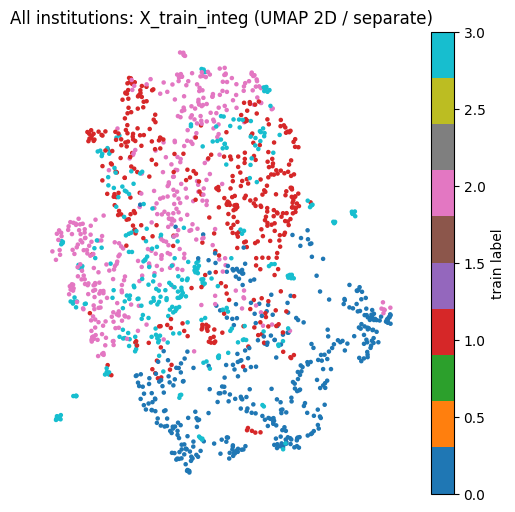

In [66]:
import umap
import matplotlib.pyplot as plt

# アンカー用 UMAP
um_tr = umap.UMAP(
    n_neighbors=40,
    min_dist=0.3,
    metric="euclidean",
    random_state=0,
)
emb_tr = um_tr.fit_transform(X_train_integ)

plt.figure(figsize=(6, 6))
sc = plt.scatter(emb_tr[:, 0], emb_tr[:, 1], c=y_train_integ, s=5, cmap="tab10")
plt.axis("off")
plt.colorbar(sc, label="train label")
plt.title("All institutions: X_train_integ (UMAP 2D / separate)")
plt.show()


c:\Users\sueya\Git-Repositories\takano_labo\dca\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


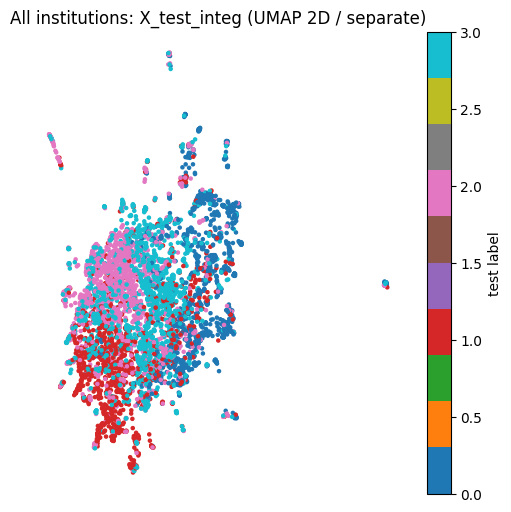

In [67]:
um_te = umap.UMAP(
    n_neighbors=40,
    min_dist=0.3,
    metric="euclidean",
    random_state=0,
)
emb_te = um_te.fit_transform(X_test_integ)

plt.figure(figsize=(6, 6))
sc = plt.scatter(emb_te[:, 0], emb_te[:, 1], c=y_test_integ, s=5, cmap="tab10")
plt.axis("off")
plt.colorbar(sc, label="test label")
plt.title("All institutions: X_test_integ (UMAP 2D / separate)")
plt.show()


In [68]:
# from src.intermediate_expression.anchor_utils import _symmetric_knn_graph
# import numpy as np

# # アンカー用 UMAP
# um_an = umap.UMAP(
#     n_neighbors=100,
#     min_dist=1,
#     metric="euclidean",
#     random_state=0,
# )
# emb_an = um_an.fit_transform(anchor_integ)

# # kNN グラフ（統合表現空間）
# k_anchor = 10
# A_anchor = _symmetric_knn_graph(anchor_integ, k_neighbors=k_anchor, metric="euclidean")
# A_bin = (A_anchor > 0).astype(int)
# i_idx, j_idx = np.where(np.triu(A_bin, k=1) > 0)

# plt.figure(figsize=(6, 6))

# # エッジ
# for i, j in zip(i_idx, j_idx):
#     plt.plot(
#         [emb_an[i, 0], emb_an[j, 0]],
#         [emb_an[i, 1], emb_an[j, 1]],
#         color="k",
#         alpha=0.3,
#         linewidth=0.3,
#     )

# # アンカー点
# sc = plt.scatter(emb_an[:, 0], emb_an[:, 1], c=anchor_integ_y, s=15, cmap="tab10")
# plt.axis("off")
# plt.colorbar(sc, label="anchor label")
# plt.title("Anchor integrated targets (UMAP 2D / separate, with kNN edges)")
# plt.show()


A shape: (1000, 1000)


c:\Users\sueya\Git-Repositories\takano_labo\dca\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


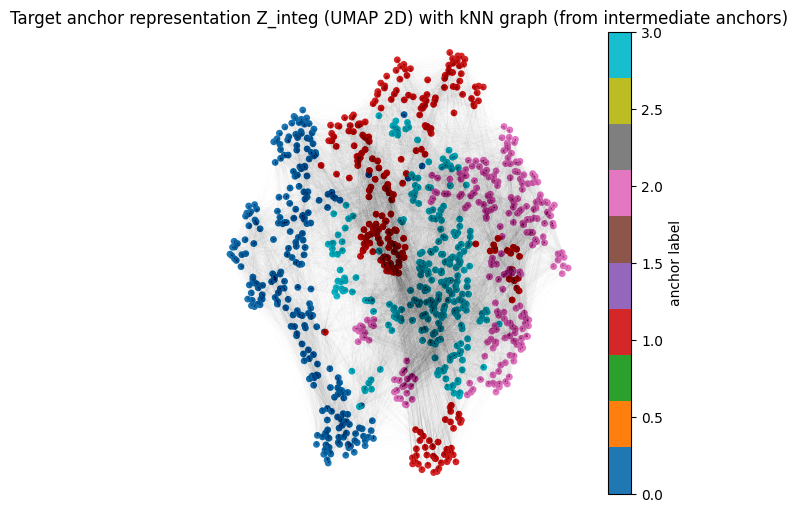

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from src.intermediate_expression.anchor_utils import _symmetric_knn_graph

# 1. 中間表現アンカーから「全機関平均 kNN グラフ」を作る
anchors_inter = inter_art.anchors_inter      # List[(r, dim_inter)]
r = anchors_inter[0].shape[0]
k_neighbors = 10

W_sum = np.zeros((r, r), dtype=float)
for A_k in anchors_inter:
    if A_k is None or A_k.size == 0:
        continue
    W_k = _symmetric_knn_graph(A_k, k_neighbors=k_neighbors, metric="euclidean")
    W_sum += W_k

W_avg = W_sum / max(len(anchors_inter), 1)
A = (W_avg > 0).astype(int)      # 0/1 クリップした隣接行列

print("A shape:", A.shape)

# 2. アンカー目標表現 Z_integ を UMAP で 2次元へ
Z = np.asarray(integ_art.Z_integ)    # (r, dim_integrate)
um = umap.UMAP(
    n_neighbors=100,
    min_dist=1,
    metric="euclidean",
    random_state=0,
)
emb_Z = um.fit_transform(Z)          # (r, 2)

# 3. エッジ付きで可視化（座標は Z_integ、グラフは中間表現由来）
i_idx, j_idx = np.where(np.triu(A, k=1) > 0)

plt.figure(figsize=(6, 6))

# エッジ
for i, j in zip(i_idx, j_idx):
    plt.plot(
        [emb_Z[i, 0], emb_Z[j, 0]],
        [emb_Z[i, 1], emb_Z[j, 1]],
        color="k",
        alpha=0.03,
        linewidth=0.1,
    )

# ノード（アンカー目標表現）をラベルで色付け
labels = anchor_integ_y
sc = plt.scatter(emb_Z[:, 0], emb_Z[:, 1], c=labels, s=15, cmap="tab10")
plt.axis("off")
plt.colorbar(sc, label="anchor label")
plt.title("Target anchor representation Z_integ (UMAP 2D) with kNN graph (from intermediate anchors)")
plt.show()
